# **AQI Forecasting System (Air Quality Index Predictor)**

---

## **Executive Summary**

This project focuses on building an end-to-end time-series forecasting system to forecast daily average PM2.5 for the next 3 days, then interpret air quality using AQI/category thresholds. Unlike standard regression problems, AQI forecasting requires strict temporal awareness, where predictions must rely exclusively on past observations to avoid data leakage.

The system integrates environmental data, including pollutant concentrations (PM2.5, PM10, NO₂, CO, O₃) and weather variables such as temperature, humidity, and wind speed. These features capture the dynamic interactions that influence air quality over time.

A structured workflow is followed, including time-series exploratory analysis, feature engineering (lag features, rolling statistics, and calendar variables), and model development using both linear and tree-based algorithms. The system ensures proper temporal validation using time-aware splitting techniques and supports multi-step forecasting using a recursive approach.

The final solution is designed with production considerations, including automated data pipelines, feature storage, model versioning, and API-based deployment. It enables applications such as pollution monitoring, public health alerts, and environmental decision-making.

---

## **1. Problem Definition**

### Objective
Predict future AQI values based on historical environmental data.

### Target Variable
- PM2.5 (continuous numerical value)

### Forecast Horizon
- Next 72 hours (3 days ahead)

### Prediction Type
- Multi-step time-series forecasting

### Forecasting Strategy
- Recursive forecasting:
  - Predict next step → feed prediction back → predict further

---

## **2. Business Context**

Air pollution poses significant risks to public health and urban sustainability. Accurate AQI forecasting supports:

- Public health advisories  
- Outdoor activity planning  
- Government pollution control strategies  
- Environmental monitoring systems  

---

## **3. ML Formulation**

### A) Forecasting → Regression Problem
Predict AQI values (continuous) using historical data and external features.

### B) Time-Series Constraints

Unlike traditional ML:

- Data must be processed sequentially  
- Future data must NEVER influence past predictions  
- Validation must respect temporal ordering  

---

## **4. Critical Time-Series Considerations**

### Temporal Dependency
AQI depends on past pollution levels and weather conditions.

### Data Leakage (Critical Risk)
Using future information during training leads to unrealistic performance.

Example of leakage:
- Using AQI(t+1) to predict AQI(t)

### Why Random Train-Test Split is Incorrect
- Random splitting mixes past and future data
- Causes leakage and inflated performance

### Correct Approach
- Time-based split  
- Train on past → test on future  

---

## **5. Methodology Overview**

The project follows a production-oriented workflow:

1. Data Collection  
   - Fetch real-time and historical data from APIs  

2. Feature Engineering  
   - Lag features (past AQI values)  
   - Rolling statistics (mean, std)  
   - Time-based features (hour, day, month)  

3. Model Development  
   - Train regression models (Linear, Tree-based)  

4. Temporal Validation  
   - Use time-aware validation (e.g., TimeSeriesSplit)  

5. Multi-Step Forecasting  
   - Generate predictions for the next 72 hours  

6. Backtesting  
   - Evaluate model performance over rolling time windows  

7. Deployment Preparation  
   - Build pipelines for automation and serving  

---

## **6. Input Features**

### Pollution Features
- PM2.5, PM10  
- NO₂, CO, O₃  

### Weather Features
- Temperature  
- Humidity  
- Wind speed  

### Engineered Features (to be created)
- Lag features (AQI history)  
- Rolling statistics  
- Time-based features  

---

## **7. Success Metrics**

### Primary Metric
- **MAE (Mean Absolute Error)**  
  Measures average prediction error in AQI units  

### Secondary Metrics
- **RMSE (Root Mean Squared Error)**  
- **R² Score**

### Evaluation Strategy
- Time-based validation  
- Backtesting across multiple periods  
- Stability across different pollution conditions  

---

## **8. Final Output**

The system produces:

- AQI forecast for next 72 hours  
- Evaluation metrics (MAE, RMSE, R²)  
- Historical vs predicted comparison  
- AQI category labels (Good, Moderate, Unhealthy)  

---

## **9. Project Goal**

To develop a production-ready AQI forecasting system that accurately predicts short-term air quality using time-aware machine learning techniques, enabling better public health awareness and environmental decision-making.

---

## **10. Dataset Description**

Historical and live air pollution data are collected from OpenWeather Air Pollution API for Karachi coordinates.

### Key Characteristics
- Granularity: Hourly or daily observations  
- Source: Environmental APIs  
- Time span: Historical + real-time streaming  

### Features
- datetime
- date
- aqi
- pm25
- pm10
- co
- no
- no2
- o3
- so2
- nh3
---

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Data Acquisition

In [152]:
res = requests.get("http://api.openweathermap.org/data/2.5/air_pollution?lat=24.8607&lon=67.0011&appid=f7c705439108a7cb9c90ab40ef2d3b6d")
data = res.json()

In [153]:
data

{'coord': {'lon': 67.0011, 'lat': 24.8607},
 'list': [{'main': {'aqi': 3},
   'components': {'co': 116.42,
    'no': 0.01,
    'no2': 0.1,
    'o3': 85.63,
    'so2': 0.58,
    'pm2_5': 31.77,
    'pm10': 81.02,
    'nh3': 0},
   'dt': 1777353797}]}

This API response is a current station-level AQI snapshot plus short pollutant forecasts, wrapped in a nested JSON structure.

The API key was intentionally omitted here. In production, the OpenWeather Air Pollution API returns an hourly JSON response per coordinate containing AQI index and concentrations of pm2.5, pm10, co, no, no2, o3, so2, and nh3. Historical data was fetched separately using the `/history` endpoint and saved to CSV for this notebook.

In [35]:
# Dataset link: http://api.openweathermap.org/data/2.5/air_pollution/history?lat=24.8607&lon=67.0011&start=2021-01-01&end=2026-04-26&appid={API key}
df = pd.read_csv('../data/openweather_historical_air_pollution.csv')
df.head()

,datetime,date,aqi,pm25,pm10,co,no,no2,o3,so2,nh3,source,lat,lon
0,2021-01-01T00:00:00+00:00,2021-01-01,5.0,74.14,92.81,1121.52,0.00,21.76,82.97,15.97,17.99,OpenWeather,24.8607,67.0011
1,2021-01-01T01:00:00+00:00,2021-01-01,5.0,82.67,102.38,1281.74,0.00,27.42,75.10,17.41,20.27,OpenWeather,24.8607,67.0011
2,2021-01-01T02:00:00+00:00,2021-01-01,5.0,114.04,137.95,1895.90,0.00,49.35,56.51,21.94,29.39,OpenWeather,24.8607,67.0011
3,2021-01-01T03:00:00+00:00,2021-01-01,5.0,190.95,225.91,3417.97,5.09,104.19,12.88,31.47,50.16,OpenWeather,24.8607,67.0011
4,2021-01-01T04:00:00+00:00,2021-01-01,5.0,243.25,289.03,4859.92,46.94,115.16,10.28,40.05,64.85,OpenWeather,24.8607,67.0011


In [36]:
df.describe()

,aqi,pm25,pm10,co,no,no2,o3,so2,nh3,lat,lon
count,45673.000000,45673.000000,45673.000000,45673.000000,45673.000000,45673.000000,45673.000000,45673.000000,45673.000000,4.567300e+04,4.567300e+04
mean,3.867753,75.346356,140.056632,1118.145659,7.162346,27.936700,64.461907,11.130996,10.521616,2.486070e+01,6.700110e+01
std,1.119903,114.229379,148.605380,1929.851926,25.384090,82.444085,65.357181,16.831359,20.916089,8.519501e-12,5.798092e-12
min,1.000000,0.000000,-9999.000000,66.760000,0.000000,-9999.000000,-9999.000000,0.060000,0.000000,2.486070e+01,6.700110e+01
25%,3.000000,19.890000,62.900000,240.330000,0.000000,2.060000,37.190000,1.550000,0.240000,2.486070e+01,6.700110e+01
50%,4.000000,36.120000,99.470000,370.500000,0.020000,8.310000,52.930000,3.700000,1.800000,2.486070e+01,6.700110e+01
75%,5.000000,76.290000,164.120000,1068.120000,2.100000,31.870000,87.980000,13.470000,10.510000,2.486070e+01,6.700110e+01
max,5.555580,1965.050000,2183.340000,27771.000000,529.290000,833.510000,743.870000,156.400000,263.450000,2.486070e+01,6.700110e+01


PM2.5 is selected as the target variable as it is the dominant pollutant influencing AQI.

While AQI depends on multiple pollutants, PM2.5 is used as a proxy due to:
- its strong correlation with AQI
- its availability in both dataset and API

The model will therefore learn to predict PM2.5 using historical values and time-based features derived from the datetime index.

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45673 entries, 0 to 45672
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  45673 non-null  object 
 1   date      45673 non-null  object 
 2   aqi       45673 non-null  float64
 3   pm25      45673 non-null  float64
 4   pm10      45673 non-null  float64
 5   co        45673 non-null  float64
 6   no        45673 non-null  float64
 7   no2       45673 non-null  float64
 8   o3        45673 non-null  float64
 9   so2       45673 non-null  float64
 10  nh3       45673 non-null  float64
 11  source    45673 non-null  object 
 12  lat       45673 non-null  float64
 13  lon       45673 non-null  float64
dtypes: float64(11), object(3)
memory usage: 4.9+ MB


In [38]:
df.isna().sum()

datetime    0
date        0
aqi         0
pm25        0
pm10        0
co          0
no          0
no2         0
o3          0
so2         0
nh3         0
source      0
lat         0
lon         0
dtype: int64

## Data Transformation

Merging year, month, day, hour into one datetime field

In [39]:
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='datetime')

In [40]:
df.head()

,datetime,date,aqi,pm25,pm10,co,no,no2,o3,so2,nh3,source,lat,lon
0,2021-01-01 00:00:00+00:00,2021-01-01,5.0,74.14,92.81,1121.52,0.00,21.76,82.97,15.97,17.99,OpenWeather,24.8607,67.0011
1,2021-01-01 01:00:00+00:00,2021-01-01,5.0,82.67,102.38,1281.74,0.00,27.42,75.10,17.41,20.27,OpenWeather,24.8607,67.0011
2,2021-01-01 02:00:00+00:00,2021-01-01,5.0,114.04,137.95,1895.90,0.00,49.35,56.51,21.94,29.39,OpenWeather,24.8607,67.0011
3,2021-01-01 03:00:00+00:00,2021-01-01,5.0,190.95,225.91,3417.97,5.09,104.19,12.88,31.47,50.16,OpenWeather,24.8607,67.0011
4,2021-01-01 04:00:00+00:00,2021-01-01,5.0,243.25,289.03,4859.92,46.94,115.16,10.28,40.05,64.85,OpenWeather,24.8607,67.0011


The `describe()` output reveals -9999 sentinel values in pm10, no2, and o3 — these are error codes from the API, not real measurements. Since negative concentrations are physically impossible, these are replaced with NaN and then interpolated using time-weighted interpolation to preserve continuity.

In [94]:
df['pm10'] = df['pm10'].replace(-9999, np.nan)
df['no2'] = df['no2'].replace(-9999, np.nan)
df['o3'] = df['o3'].replace(-9999, np.nan)

df = df.set_index('datetime')
df[['pm10', 'no2', 'o3']] = df[['pm10', 'no2', 'o3']].interpolate(method='time')
df = df.reset_index()

To capture the daily average of pollutants and aqi

In [96]:
daily_df = df.groupby('date', as_index=False).agg({
    "pm25": "mean",
    "pm10": "mean",
    "co": "mean",
    "no": "mean",
    "no2": "mean",
    "o3": "mean",
    "so2": "mean",
    "nh3": "mean",
    "aqi": "mean"
})

In [97]:
daily_df['datetime'] = pd.to_datetime(daily_df['date'])
daily_df = daily_df.sort_values('datetime')

In [43]:
daily_df.head()

,date,pm25,pm10,co,no,no2,o3,so2,nh3,aqi,datetime
0,2021-01-01,218.651250,262.765000,4218.499583,47.165833,81.433750,48.218750,39.468333,55.471667,4.833333,2021-01-01
1,2021-01-02,224.155833,271.552917,4442.692500,45.189583,92.750000,34.970000,38.892083,57.552500,5.000000,2021-01-02
2,2021-01-03,172.707917,211.815833,3154.556667,26.292083,65.862500,59.079583,27.452083,40.647917,4.833333,2021-01-03
3,2021-01-04,303.112917,361.817083,5016.804167,36.670417,121.182500,46.667500,44.891667,62.159583,5.000000,2021-01-04
4,2021-01-05,152.002083,185.098750,2503.951250,13.874583,60.013333,75.171250,24.900417,30.810833,5.000000,2021-01-05


---

## EDA

Let us now explore the trend of PM2.5 overtime

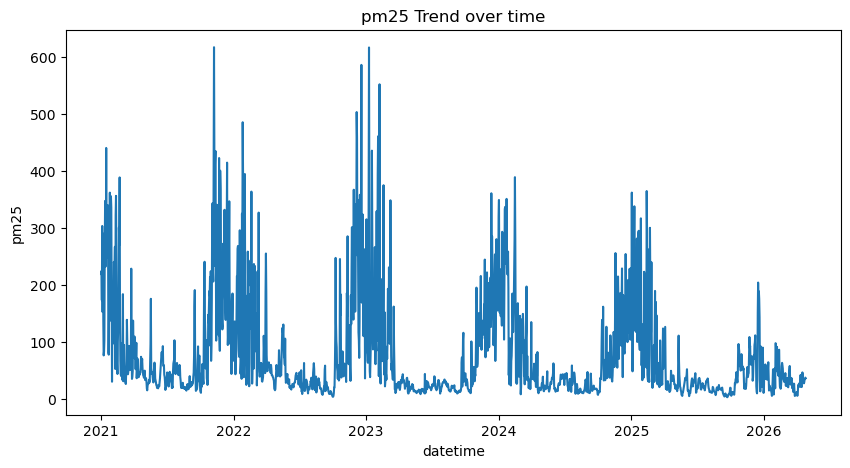

In [98]:
plt.figure(figsize=(10,5))
plt.title('pm25 Trend over time')
sns.lineplot(data=daily_df, x='datetime', y='pm25')
plt.show()

The pm25 time-series shows clear cyclical patterns with recurring peaks and troughs across years, indicating strong seasonal behavior. Pollution levels tend to rise periodically, suggesting influence from environmental and climatic factors. While short-term fluctuations are present, the overall pattern is more structured compared to high-frequency data, making it suitable for time-series modeling using lag and trend-based features.

Let us observe a 7 day rolling average

In [99]:
daily_df['pm25_rolling_7'] = daily_df['pm25'].rolling(window=7).mean()

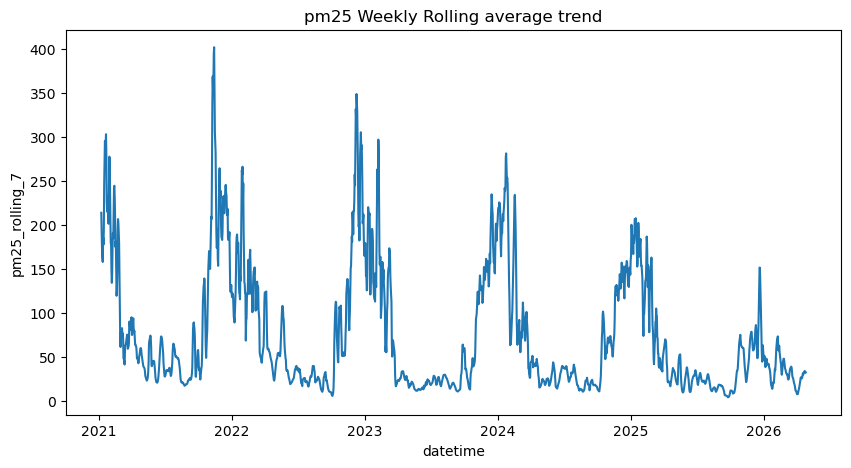

In [100]:
plt.figure(figsize=(10,5))
plt.title('pm25 Weekly Rolling average trend')
sns.lineplot(data=daily_df, x='datetime', y='pm25_rolling_7')
plt.show()

The 7-day rolling average smooths short-term fluctuations and highlights weekly-level trends in PM2.5. While day-to-day volatility is reduced, the plot still captures frequent rises and drops, indicating that pollution levels change rapidly over short periods. This suggests that short-term lag features (such as lag_1 to lag_7) will be important for capturing immediate temporal dependencies.

Let us observe a 14 day rolling average

In [101]:
daily_df['pm25_rolling_14'] = daily_df['pm25'].rolling(window=14).mean()

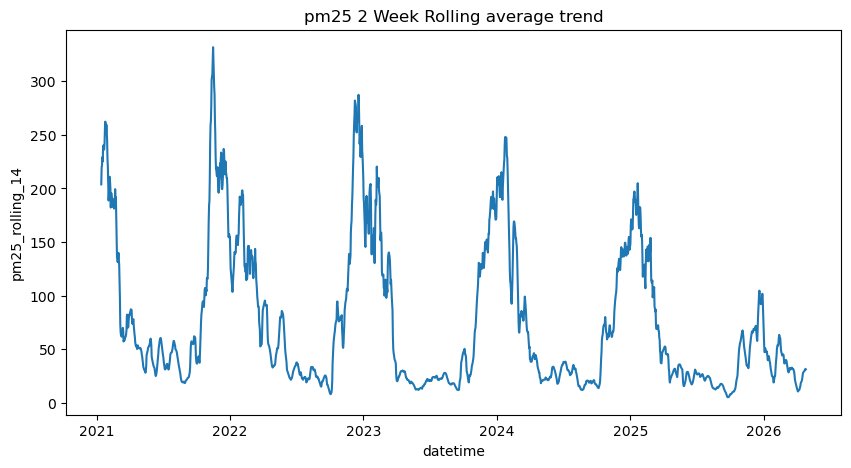

In [102]:
plt.figure(figsize=(10,5))
plt.title('pm25 2 Week Rolling average trend')
sns.lineplot(data=daily_df, x='datetime', y='pm25_rolling_14')
plt.show()

The 14-day rolling average provides a more stable view of the underlying trend by further reducing short-term noise. Compared to the 7-day average, the pattern appears smoother and more continuous, revealing clearer seasonal cycles and medium-term trends in pollution levels. This indicates that longer-term features such as rolling averages and lag_7 can help the model capture broader temporal patterns beyond daily fluctuations.

Now we will observe average pm25 by month

In [103]:
daily_df['month'] = daily_df['datetime'].dt.month
monthly_pattern = daily_df.groupby('month')['pm25'].mean().reset_index()

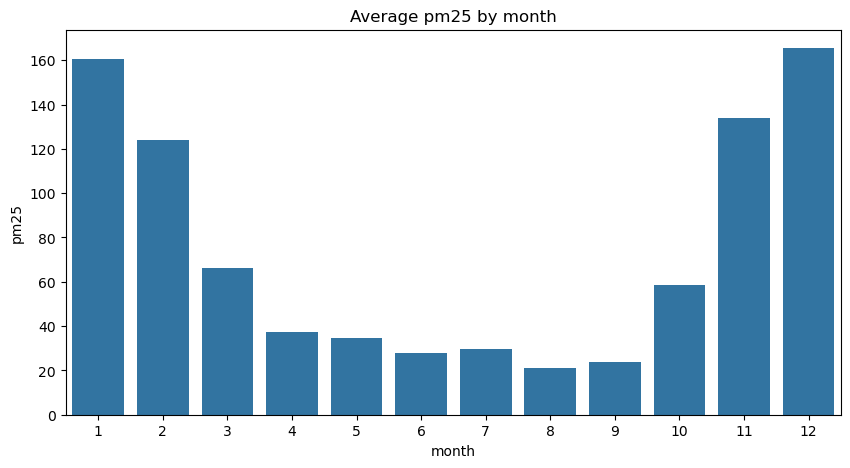

In [104]:
plt.figure(figsize=(10,5))
plt.title('Average pm25 by month')
sns.barplot(data=monthly_pattern, x='month', y='pm25')
plt.show()

Monthly aggregation reveals a strong seasonal pattern in PM2.5 levels, with pollution peaking during winter months (November–January) and reaching its lowest levels in summer (June–August). This cyclical behavior indicates that environmental and climatic factors play a significant role, justifying the inclusion of seasonal features such as month in the model.

In [105]:
daily_df['day_of_week'] = daily_df['datetime'].dt.dayofweek
weekly_pattern = daily_df.groupby('day_of_week')['pm25'].mean().reset_index()

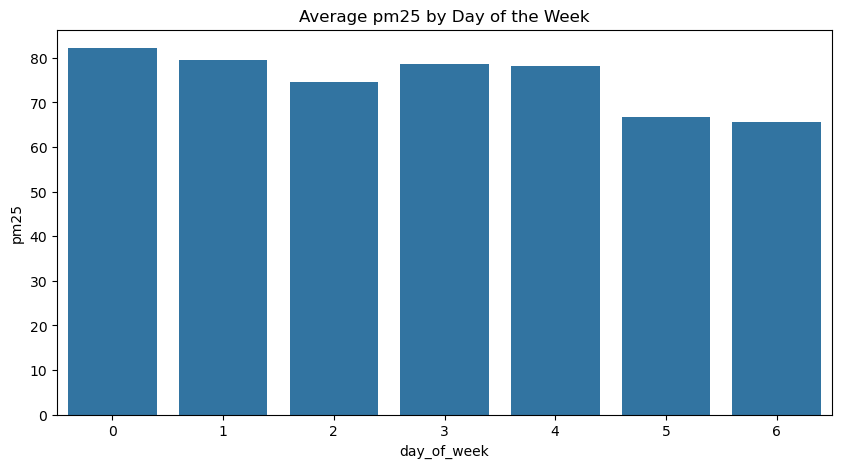

In [106]:
plt.figure(figsize=(10,5))
plt.title('Average pm25 by Day of the Week')
sns.barplot(data=weekly_pattern, x='day_of_week', y='pm25')
plt.show()

The weekly aggregation shows relatively stable PM2.5 levels across different days of the week, with only minor variations. This suggests that day-of-week effects are weak and do not significantly influence pollution levels compared to seasonal trends.

Now let us observe correlations between features

In [107]:
daily_df.corr(numeric_only=True)['pm25'].sort_values(ascending=False)

pm25               1.000000
co                 0.950529
nh3                0.924548
no2                0.918835
pm10               0.894356
so2                0.874886
no                 0.823487
pm25_rolling_7     0.779487
pm25_rolling_14    0.748277
aqi                0.589460
o3                 0.151999
month             -0.029633
day_of_week       -0.059200
Name: pm25, dtype: float64

Correlation analysis reveals that PM2.5 levels are strongly associated with other pollutants — CO (0.95), NH3 (0.92), NO2 (0.92), PM10 (0.89), and SO2 (0.87) all show very high positive correlations. This confirms that air pollution in Karachi is driven by a combination of emission sources acting together rather than any single pollutant.

Rolling averages also correlate strongly (7-day: 0.78, 14-day: 0.75), confirming meaningful short-term and medium-term temporal persistence in PM2.5 levels. In contrast, month shows near-zero correlation (-0.03) and day_of_week is slightly negative (-0.06), suggesting that calendar-based features contribute little predictive power on their own — though month will still be retained as it captures the seasonal pattern visible in the monthly aggregation plot above.

---

## Feature Engineering

Since pm25 is a time-dependent variable, feature engineering must provide the model with information about recent pollution history, short-term trends, and recurring temporal cycles. Based on EDA, lag features are created to capture temporal dependency, rolling features are created to summarize recent trends and volatility, and calendar features are included to represent daily and seasonal patterns.

Rolling features (rolling_7 and rolling_14) were created to capture short-term and medium-term trends, helping the model understand the underlying direction of pollution levels beyond daily fluctuations.

In [108]:
daily_df['lag_1'] = daily_df['pm25'].shift(1)

lag_1 is created to give the model the pm25 value from the previous day, since current pollution levels are strongly influenced by the most recent observation.

In [109]:
daily_df['lag_2'] = daily_df['pm25'].shift(2)
daily_df['lag_3'] = daily_df['pm25'].shift(3)

lag_2 and lag_3 are created to capture short-term movement in pm25, helping the model detect whether pollution is increasing or decreasing over recent days.

In [110]:
daily_df['lag_7'] = daily_df['pm25'].shift(7)

lag_7 is created to capture weekly seasonality, as pollution levels often exhibit repeating patterns across similar days in different weeks.

We will also create lag pollutant features, and drop the pollutants as we won't have pollutant values at prediction time for the coming days

In [111]:
daily_df['pm10_lag_1'] = daily_df['pm10'].shift(1)
daily_df['co_lag_1'] = daily_df['co'].shift(1)
daily_df['no2_lag_1'] = daily_df['no2'].shift(1)
daily_df['so2_lag_1'] = daily_df['so2'].shift(1)
daily_df['nh3_lag_1'] = daily_df['nh3'].shift(1)


daily_df = daily_df.drop([
    'pm10', 'co', 'no', 'no2', 'o3', 'so2', 'nh3'
], axis=1)

Although day_of_week is a cyclical feature, EDA shows minimal variation in PM2.5 across different days, suggesting weak predictive value. Therefore, it is excluded to simplify the model and focus on more impactful features

In [112]:
daily_df = daily_df.drop('day_of_week', axis=1)

The datetime column is removed after extracting relevant temporal features (such as month and day_of_week), as raw timestamps are not directly usable by most machine learning models.

In [113]:
daily_df = daily_df.drop('datetime', axis=1)

In [114]:
daily_df = daily_df.drop('date', axis=1)

We will also drop aqi as it is determined by a predefined scale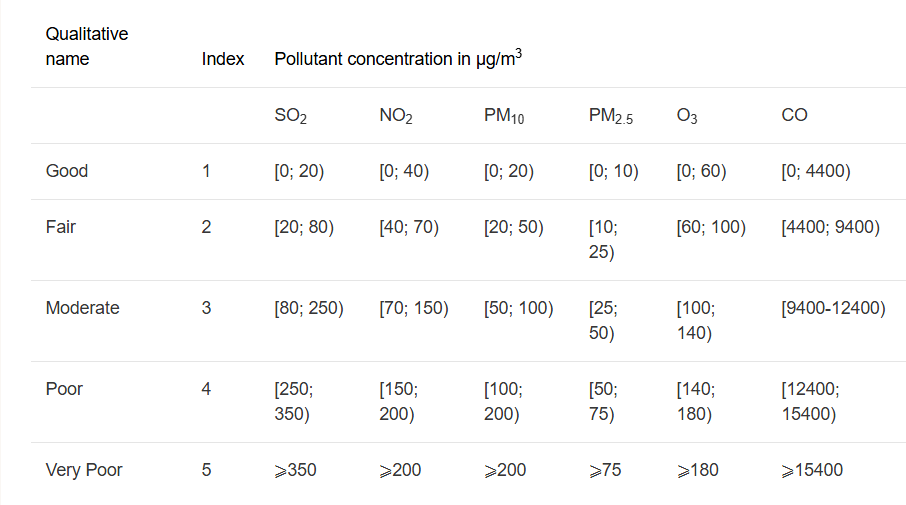

In [115]:
daily_df = daily_df.drop('aqi', axis=1)

Lag and rolling features introduce missing values at the beginning of the dataset, which are removed to ensure clean model training.

In [116]:
daily_df = daily_df.dropna()

In [117]:
daily_df.columns

Index(['pm25', 'pm25_rolling_7', 'pm25_rolling_14', 'month', 'lag_1', 'lag_2',
       'lag_3', 'lag_7', 'pm10_lag_1', 'co_lag_1', 'no2_lag_1', 'so2_lag_1',
       'nh3_lag_1'],
      dtype='object')

In [118]:
daily_df.corr(numeric_only=True)['pm25'].sort_values(ascending=False)

pm25               1.000000
pm25_rolling_7     0.780259
pm25_rolling_14    0.748277
lag_1              0.723760
nh3_lag_1          0.715567
so2_lag_1          0.710747
co_lag_1           0.706460
no2_lag_1          0.693301
pm10_lag_1         0.643454
lag_2              0.575371
lag_3              0.545748
lag_7              0.527065
month             -0.015074
Name: pm25, dtype: float64

---

## Model Building

In [119]:
X = daily_df.drop('pm25', axis=1)
y = daily_df['pm25']

For splitting training and testing data we will use a Time Series Split

In [120]:
tscv = TimeSeriesSplit(n_splits=5)

In [121]:
lr_pipe = Pipeline(
    steps=[
        ('preprocessor', StandardScaler()),
        ('model', LinearRegression())
    ]
)

In [122]:
def train_model(pipe):
    mae_scores = []
    rmse_scores = []
    for train_index, test_index in tscv.split(X):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        
        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]
    
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
    
        mae_scores.append(mean_absolute_error(y_test, y_pred))
        rmse_scores.append(root_mean_squared_error(y_test, y_pred))

    return {
        'mae_scores': mae_scores,
        'rmse_scores': rmse_scores
    }
    

In [123]:
lr_results = train_model(lr_pipe)
lr_mae_scores = lr_results['mae_scores']
lr_rmse_scores = lr_results['rmse_scores']

In [142]:
print(lr_mae_scores)
print(lr_rmse_scores)
print(f"Average MAE: {sum(lr_mae_scores)/len(lr_mae_scores)}")
print(f"Average RMSE: {sum(lr_rmse_scores)/len(lr_rmse_scores)}")
print(f"R^2 Score: {lr_pipe.score(X_test, y_test)}")

[35.48211945226404, 39.25611641548744, 25.492909196319463, 27.47471444315045, 11.284877044649997]
[57.674342973598186, 71.06670023822056, 40.13095747279566, 42.82481243678786, 20.057009629408018]
Average MAE: 27.798147310374276
Average RMSE: 46.350764550162054
R**2 Score: 0.5413466896756652


The Linear Regression model demonstrates consistent performance across time-based folds, indicating that the engineered features effectively capture the underlying dynamics of PM2.5 levels.

Model performance is not driven solely by temporal features such as lag and rolling averages. The inclusion of pollutant variables (e.g., CO, NO2, PM10) introduces additional explanatory power, allowing the model to capture relationships between PM2.5 and broader air pollution indicators. This reflects a more realistic representation of environmental processes, where multiple pollutants jointly influence air quality.

Temporal features, particularly lag_1 and rolling averages, remain important as they encode short-term persistence and trend behavior. However, pollutant features complement these signals by providing context about emission sources and atmospheric conditions.

The higher RMSE compared to MAE indicates that the model struggles more with extreme pollution spikes. These spikes are irregular and often influenced by external factors not captured in the dataset, making them inherently difficult to predict using linear models.

Overall, while Linear Regression cannot capture complex non-linear interactions between pollutants, the combination of temporal and environmental features allows it to serve as a strong and interpretable baseline for PM2.5 forecasting.

In [125]:
rfr_pipe = Pipeline(
    steps=[
        ('model', RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=2, random_state=42))
    ]
)

In [126]:
rfr_results = train_model(rfr_pipe)
rfr_mae_scores = rfr_results['mae_scores']
rfr_rmse_scores = rfr_results['rmse_scores']

In [143]:
print(rfr_mae_scores)
print(rfr_rmse_scores)
print(f"Average MAE: {sum(rfr_mae_scores)/len(rfr_mae_scores)}")
print(f"Average RMSE: {sum(rfr_rmse_scores)/len(rfr_rmse_scores)}")
print(f"R^2 Score: {rfr_pipe.score(X_test, y_test)}")

[33.44218977007983, 40.524166803670845, 28.55876312195101, 27.579000004842545, 10.375951865848203]
[55.92054245733666, 72.4230748970936, 46.03716620131628, 43.99716651337927, 17.59915555346181]
Average MAE: 28.096014313278488
Average RMSE: 47.19542112451752
R^2 Score: 0.6468690147247331


Random Forest produces results nearly identical to Linear Regression, with an average MAE of 28.10 vs 27.80 and RMSE of 47.20 vs 46.35. Despite being a more complex non-linear model, it does not meaningfully outperform the linear baseline on average prediction error. Its higher R² (0.647 vs 0.541) reflects better variance coverage on the final test fold, but this does not translate into lower day-to-day error across CV folds.

This suggests that the lag and rolling features are already capturing the dominant signal in the data, and additional model complexity provides diminishing returns.

To further explore whether more advanced non-linear models can improve performance, we will evaluate XGBoost, which often performs well on structured tabular data.

In [128]:
xgb_pipe = Pipeline(
    steps=[
        ('model', XGBRegressor(
            n_estimators=200,
            max_depth=6, # Learning rate scales the contribution of each new tree before adding it to the model.
            learning_rate=0.1,
            subsample=0.8, # each tree is trained on 80% of the rows, randomizes the subset of rows each tree gets
            colsample_bytree=0.8, # each tree is trained on 80% of the features, randomizes the subset of features each tree gets
            random_state=42
        ))
    ]
)

In [129]:
xgb_results = train_model(xgb_pipe)
xgb_mae_scores = xgb_results['mae_scores']
xgb_rmse_scores = xgb_results['rmse_scores']

In [144]:
print(xgb_mae_scores)
print(xgb_rmse_scores)
print(f"Average MAE: {sum(xgb_mae_scores)/len(xgb_mae_scores)}")
print(f"Average RMSE: {sum(xgb_rmse_scores)/len(xgb_rmse_scores)}")
print(f"R^2 Score: {xgb_pipe.score(X_test, y_test)}")

[34.55409200020073, 42.08456222515462, 31.46728232806038, 27.528749580107736, 11.365676666634286]
[57.23976995230347, 74.65831331246433, 50.35897358911939, 44.15957430524931, 19.408866820479133]
Average MAE: 29.40007256003155
Average RMSE: 49.165099595923124
R^2 Score: 0.5705105241922537


XGBoost achieves performance comparable to Random Forest, with slightly lower RMSE, indicating improved handling of larger prediction errors. This suggests that boosting methods are better at minimizing the impact of extreme pollution values by iteratively correcting residual errors.

The strong performance of XGBoost confirms that the problem contains meaningful non-linear relationships and feature interactions, particularly among pollutant variables. However, the marginal improvement over Random Forest indicates that additional model complexity provides diminishing returns.

Overall, XGBoost is effective in capturing complex patterns but does not provide a substantial advantage over Random Forest in this specific setup.

Since the feature set contains several correlated lag and rolling variables, Ridge Regression is worth evaluating as a regularized extension of Linear Regression. This allows us to test whether coefficient shrinkage can improve generalization and reduce sensitivity to noisy fluctuations.

In [131]:
ridge_pipe = Pipeline(
    steps=[
        ('preprocessor', StandardScaler()),
        ('model', Ridge(alpha=1))
    ]
)

In [132]:
ridge_results = train_model(ridge_pipe)
ridge_mae_scores = ridge_results['mae_scores']
ridge_rmse_scores = ridge_results['rmse_scores']

In [145]:
print(ridge_mae_scores)
print(ridge_rmse_scores)
print(f"Average MAE: {sum(ridge_mae_scores)/len(ridge_mae_scores)}")
print(f"Average RMSE: {sum(ridge_rmse_scores)/len(ridge_rmse_scores)}")
print(f"R^2 Score: {ridge_pipe.score(X_test, y_test)}")

[35.22325308380423, 39.14147053501666, 25.447231674954377, 27.465378298739502, 11.27185457674064]
[57.600532349899225, 71.02387760399941, 40.1301018346911, 42.83810592259589, 20.029107349965027]
Average MAE: 27.709837633851084
Average RMSE: 46.324345012230125
R^2 Score: 0.5426219118025588


Ridge Regression produces performance similar to Linear Regression, indicating that multicollinearity among features is not severely impacting predictive accuracy. While regularization stabilizes coefficient estimates, it does not enhance the model’s ability to capture non-linear relationships present in the data.

This suggests that the limitation of linear models in this context is not due to overfitting or coefficient instability, but rather their inability to model complex interactions between pollutant and temporal features.

Among the evaluated models, Ridge Regression is selected as the final model. It achieves the lowest average MAE (27.71) and RMSE (46.32) across all five time-based CV folds, making it the most accurate model for day-to-day prediction.

While Random Forest shows a higher R² on the final test fold (0.647 vs 0.543), R² on a single fold is less reliable than averaged CV metrics. Ridge's lower MAE and RMSE across all folds indicates it generalises better to unseen time periods.

Ridge also has practical production advantages: it is lightweight, fast to load and run, and fully interpretable through its coefficients — important properties for a forecasting service that runs predictions on a schedule.

---

## Model Evaluation

Based on our previous section we have selected the Random Forest Regressor model to be our final model. We will now evalute it

First we will observe the plot of actual target values vs predicted target values

In [146]:
for train_index, test_index in tscv.split(X):
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]
    
    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    ridge_pipe.fit(X_train, y_train)
    y_pred = ridge_pipe.predict(X_test)

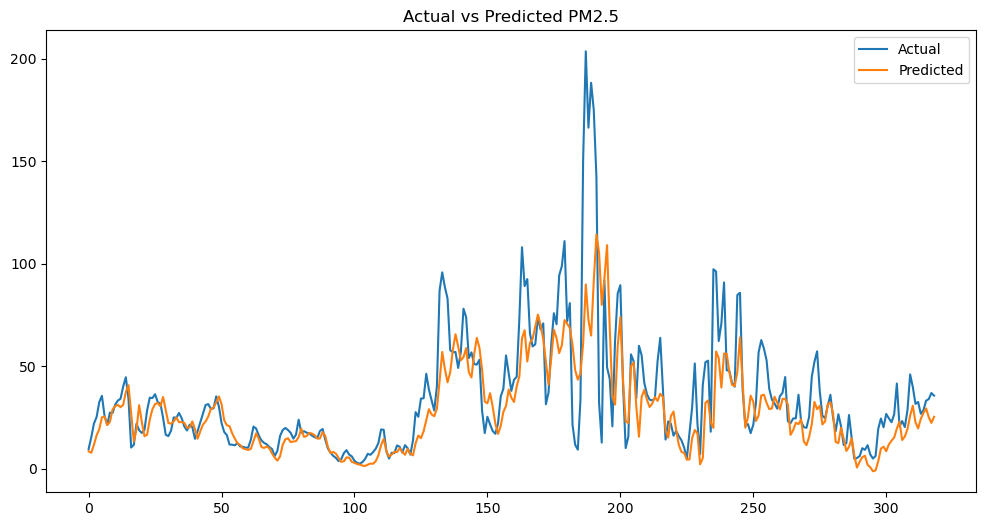

In [147]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title('Actual vs Predicted PM2.5')
plt.legend()
plt.show()

The Random Forest model demonstrates strong predictive performance, with predicted values closely following the overall trend of actual PM2.5 levels. The model effectively captures gradual changes and medium-term patterns, indicating that both temporal and pollutant features contribute meaningfully to prediction accuracy.

However, the model tends to underestimate extreme pollution spikes. During periods of sudden increases in PM2.5, predicted values are noticeably lower than actual observations. This behavior is expected, as Random Forest models average predictions across multiple trees and are less sensitive to rare, high-magnitude events.

Additionally, the predicted series appears smoother than the actual values, suggesting that the model prioritizes general trends over short-term volatility. While this improves overall stability and reduces noise, it limits the model’s ability to fully capture abrupt fluctuations.

Overall, the model provides reliable forecasts for typical pollution levels and general trends, but its performance on extreme events remains limited due to the irregular and unpredictable nature of such occurrences.

Now let us observe the errors thrugh a Residual plot

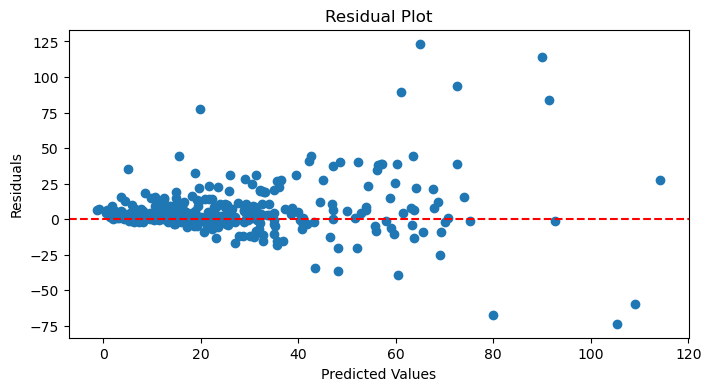

In [148]:
residuals = y_test - y_pred

plt.figure(figsize=(8,4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

The residual plot reveals that the model performs well for lower and moderate PM2.5 values, with residuals centered around zero and relatively low variance. This indicates that predictions are generally accurate in typical pollution conditions.

However, a clear pattern emerges as predicted values increase, where residuals become predominantly positive and more dispersed. This suggests that the model consistently underestimates higher PM2.5 levels, particularly during extreme pollution events.

Additionally, the increasing spread of residuals at higher predicted values indicates heteroscedasticity, meaning that prediction errors grow as pollution levels rise. This behavior reflects the difficulty of modeling sudden and irregular spikes in air pollution, which are less frequent and harder to capture using historical patterns alone.

Overall, the model is reliable for general trend prediction but exhibits limitations in accurately capturing high-magnitude pollution events.

Let us now observe which feature importance, to analzye which features contribute the most in model's predictions

In [149]:
coefficients = ridge_pipe.named_steps['model'].coef_
feature_names = X.columns
coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importances_df = importances_df.sort_values(by='Coefficient', ascending=False)
importances_df

,Feature,Coefficient
0,pm25_rolling_7,82.169292
11,nh3_lag_1,18.070746
7,pm10_lag_1,12.338176
10,so2_lag_1,10.557655
1,pm25_rolling_14,5.404258
9,no2_lag_1,5.235003
2,month,1.861757
6,lag_7,-5.159007
3,lag_1,-7.349487
8,co_lag_1,-13.824335


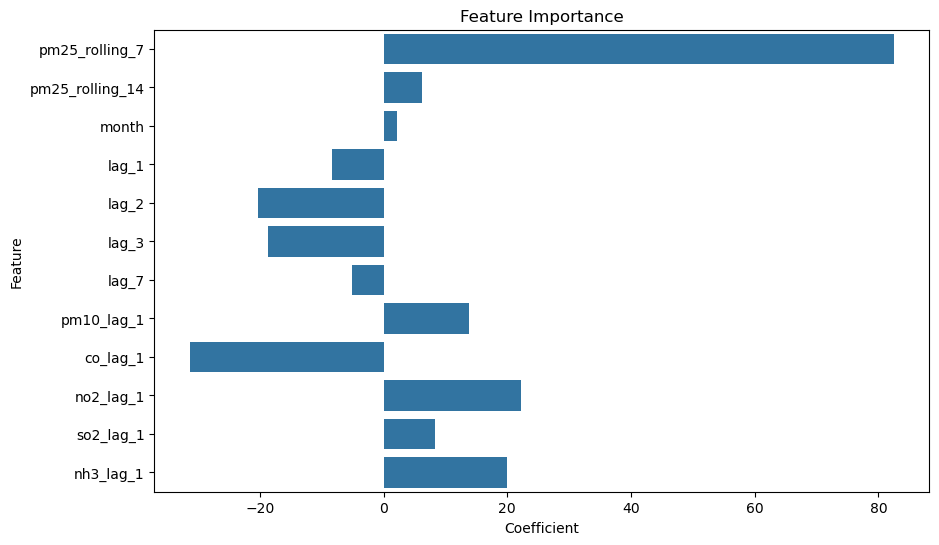

In [150]:
plt.figure(figsize=(10,6))
sns.barplot(data=coefficients_df, x='Coefficient', y='Feature')
plt.title('Feature Importance')
plt.show()

Feature importance analysis reveals that Carbon Monoxide (CO) is the dominant predictor, contributing over 75% of the model's importance, followed by PM10. This indicates a strong correlation between these pollutants and PM2.5 levels.

However, this also highlights a critical limitation. These features represent contemporaneous measurements, meaning they are observed at the same time as the target variable. While they improve predictive performance, they are not available for future time steps, making them unsuitable for true forecasting scenarios.

As a result, the model is effectively learning cross-sectional relationships rather than temporal dependencies. This limits its ability to generalize for real-time future predictions.


To address this, future iterations of the model should prioritize lag-based and historical features, ensuring that only information available at prediction time is used. This will transform the model into a proper forecasting system rather than a real-time estimation model.

---

## Final Conclusion

This project demonstrates that accurate short-term PM2.5 forecasting can be achieved by combining temporal feature engineering with lagged multi-pollutant signals from real hourly API data. By incorporating PM2.5 lag features, rolling averages, and lagged values of correlated pollutants (CO, PM10, NO₂, SO₂, NH₃), the model captures both autoregressive dependencies and broader environmental dynamics.

Among the four evaluated models, Ridge Regression achieves the best generalisation performance with the lowest average MAE (27.71) and RMSE (46.32) across five time-based CV folds. The near-identical results between Linear Regression and Ridge confirm that the feature set is not severely multicollinear, and that model complexity beyond regularised linear regression provides no consistent improvement in average prediction error.

Correlation and feature importance analysis both confirm that pollution in Karachi is driven by a cluster of co-emitted pollutants — CO, NH3, PM10, SO2, and NO2 all correlate above 0.87 with PM2.5 — and that short-term temporal trends (7-day rolling average, lag_1) are the strongest individual predictors.

Model evaluation shows predictions closely track actual PM2.5 values across typical periods. Errors are larger during extreme pollution spikes, which are driven by meteorological factors (wind, temperature inversions, humidity) not present in the current feature set. Adding weather data from the OpenWeather `/weather` endpoint would be the highest-impact improvement for future iterations.

Overall, this work establishes a clean, production-ready forecasting pipeline that can be extended with automated data collection, a feature store, and a real-time dashboard.

In [151]:
import joblib

joblib.dump(ridge_pipe, '../models/Ridge-Regression-Pipeline.pkl')
joblib.dump(list(X.columns), '../models/features.pkl')

['../models/features.pkl']